# 🚀 Notebook 3: Training, Two-Stage + Ablation + BLEU

This is the rewritten training pipeline. Compared to your previous run (which overfit hard, val gap +1.4 on CrossAttention, captions hallucinating), the changes here address the root causes from the diagnosis:

| Problem | Fix |
|---|---|
| 49K-token CLIP vocab → 25M-param output layer overfitting | **Reduced vocab (~5K) from Notebook 2**, then **weight-tied** input embedding ↔ output → ~0 extra output params |
| 5.8M–7.4M params on ~10K samples | `HIDDEN_DIM` 512→384, drop 0.4→**0.5**, total ~3M params |
| Multinomial sampling at inference → noisy garbage | **Beam search** (k=4) with length penalty + no-repeat-3gram + UNK/SOS blocking |
| Model never learned vision→language grounding before being asked to add emotion | **Two-stage training: Stage A** trains Baseline on NEUTRAL captions to learn grounded captioning; **Stage B** fine-tunes 4 emotion variants from those weights |
| Reported "best" by train loss → wrong winner | Best model = **lowest val loss + highest BLEU-4**; full per-emotion BLEU breakdown |
| Inference shown only with cherry-picked image | BLEU computed on full test set + qualitative grid on 3 images |

## What you should see if it works

After this notebook runs end-to-end:
- Stage A val loss should drop to **~3.0–3.3** (perplexity 20–28). That's the floor — the visual→language pipeline is working.
- Stage B val loss for emotion variants should be **~3.5–4.0** (slightly higher because emotion adds variability).
- Test **BLEU-4 around 0.05–0.12**. With a single reference per emotion, this is the realistic range.
- Generated captions should be **grounded** (mention objects in the image) and **emotionally tinted** (word choice changes by emotion) — not the rambling poetry from before.

## Inputs (from Notebook 2)

- `processed_captions.pkl` — captions tokenized into reduced LOCAL vocab
- `vocab_mapping.pkl` — local↔CLIP id map + special token ids
- `train.csv`, `val.csv`, `test.csv`
- Flickr8k images (mounted as a Kaggle dataset)


## ⚙️ Step 1: Setup

In [13]:
import os, time, json, pickle, random, math
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

# ── Paths — update to where Notebook 2's outputs are mounted ─────────────────
WORKING_DIR    = '/kaggle/working'
FEATURE_DIR    = f'{WORKING_DIR}/clip_features'
os.makedirs(FEATURE_DIR, exist_ok=True)

# These three should point to the OUTPUTS of Notebook 2
TOKENIZED_DIR  = '/kaggle/input/datasets/muhammadasjadali/tokenized8k'   # ← update
SPLIT_DIR      = TOKENIZED_DIR
CAPTIONS_PKL   = f'{TOKENIZED_DIR}/processed_captions.pkl'
VOCAB_PKL      = f'{TOKENIZED_DIR}/vocab_mapping.pkl'

# Where the Flickr8k images are
IMG_BASE_DIR   = '/kaggle/input/datasets/adityajn105/flickr8k/Images'

# ── Hyperparameters ──────────────────────────────────────────────────────────
HIDDEN_DIM   = 384      # was 512
WORD_DIM     = 384      # tied with output → must match HIDDEN_DIM (or add a projection)
EMO_DIM      = 64       # emotion embedding (per proposal)
VISUAL_DIM   = 768      # CLIP ViT-B/32 patch dim
EMBED_DROP   = 0.5      # was 0.4
LSTM_DROP    = 0.4      # was 0.3
N_EMOTIONS   = 6

BATCH_SIZE        = 64
STAGE_A_EPOCHS    = 50     # neutral pretraining
STAGE_B_EPOCHS    = 33     # emotion fine-tuning
WARMUP_EPOCHS     = 5
BASE_LR_STAGE_A   = 5e-4
BASE_LR_STAGE_B   = 5e-4   # smaller LR for fine-tune
WEIGHT_DECAY      = 1e-4
GRAD_CLIP         = 5.0
ES_PATIENCE       = 5
LABEL_SMOOTHING   = 0.099
print("✅ Setup ok")

Device : cuda
GPU    : Tesla T4
✅ Setup ok


## 📚 Step 2: Load Vocab Mapping & Decoder Utilities

In [14]:
with open(VOCAB_PKL, 'rb') as f:
    V = pickle.load(f)

# FIX: Dynamically set VOCAB_SIZE based on the highest index in your mapping.
# This ensures that ID 5741 ('vacuum') and any others are within model bounds.
VOCAB_SIZE   = max(V['local2clip'].keys()) + 1

PAD_ID       = V['pad_id']     # 0
SOS_ID       = V['sos_id']     # 1
EOS_ID       = V['eos_id']     # 2
UNK_ID       = V['unk_id']     # 3
MAX_SEQ_LEN  = V['max_seq_len']
EMOTIONS     = V['emotions']
EMOTION2ID   = {e: i for i, e in enumerate(EMOTIONS)}
local2clip   = V['local2clip']
clip2local   = V['clip2local']

# CLIP tokenizer for decoding back to text
from transformers import CLIPTokenizer
clip_tokenizer = CLIPTokenizer.from_pretrained('openai/clip-vit-base-patch32')
clip_tokenizer.add_special_tokens({'pad_token': '[PAD]'})


def local_ids_to_text(local_ids):
    """Decode a list of LOCAL ids → readable string. Stops at EOS."""
    clip_ids = []
    for lid in local_ids:
        lid = int(lid)
        if lid == EOS_ID or lid == PAD_ID:
            break
        if lid in (SOS_ID, UNK_ID):
            continue
        cid = local2clip.get(lid)
        if cid is not None:
            clip_ids.append(cid)
    return clip_tokenizer.decode(clip_ids).strip()


# Smoke test
print(f"Adjusted Vocab size : {VOCAB_SIZE:,}")
print(f"Special             : PAD={PAD_ID}  SOS={SOS_ID}  EOS={EOS_ID}  UNK={UNK_ID}")
print(f"Emotions            : {EMOTIONS}")
print(f"Decode test         : {local_ids_to_text([SOS_ID, 100, 101, 102, EOS_ID])!r}")

Adjusted Vocab size : 9,200
Special             : PAD=0  SOS=1  EOS=2  UNK=3
Emotions            : ['humorous', 'joyful', 'romantic', 'sad', 'tense']
Decode test         : 'wooden jumping beach'


## 🖼️ Step 3: CLIP Visual Feature Pre-Extraction

Run once per Kaggle session. Each image becomes a `(50, 768)` tensor (49 spatial patches + 1 CLS token). After extraction the CLIP model is freed.


In [15]:
from transformers import CLIPProcessor, CLIPVisionModel

CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_vision    = CLIPVisionModel.from_pretrained(CLIP_MODEL_NAME).to(device).eval()

# Collect every image we'll ever need
train_df = pd.read_csv(f'{SPLIT_DIR}/train.csv')
val_df   = pd.read_csv(f'{SPLIT_DIR}/val.csv')
test_df  = pd.read_csv(f'{SPLIT_DIR}/test.csv')
all_imgs = pd.concat([train_df, val_df, test_df]).drop_duplicates('image_id')

print(f"Need features for {len(all_imgs):,} unique images")
missing = []
for img_id in all_imgs['image_id'].unique():
    pt_path = os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt")
    if not os.path.exists(pt_path):
        missing.append(img_id)
print(f"Already extracted: {len(all_imgs) - len(missing):,}")
print(f"Missing          : {len(missing):,}")

with torch.no_grad():
    for img_id in tqdm(missing, desc='CLIP feature extraction'):
        try:
            img      = Image.open(os.path.join(IMG_BASE_DIR, img_id)).convert('RGB')
            inputs   = clip_processor(images=img, return_tensors='pt').to(device)
            outputs  = clip_vision(**inputs)
            feat     = outputs.last_hidden_state.cpu().squeeze(0)   # (50, 768)
            torch.save(feat, os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt"))
        except Exception as e:
            print(f"  ⚠ {img_id}: {e}")

del clip_vision, clip_processor
torch.cuda.empty_cache()
print("✅ CLIP features ready, GPU cleared")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.wei

Need features for 7,762 unique images
Already extracted: 6,627
Missing          : 1,135


CLIP feature extraction:   0%|          | 0/1135 [00:00<?, ?it/s]

✅ CLIP features ready, GPU cleared


## 📦 Step 4: Dataset & DataLoaders

The dataset can serve **either** the emotion caption (Stage B target) **or** the neutral caption (Stage A target) — controlled by the `target` argument.


In [16]:
# Load the tokenized captions
with open(CAPTIONS_PKL, 'rb') as f:
    all_processed = pickle.load(f)

print(f"Total tokenized rows: {len(all_processed):,}")

# Group by split
by_split = {'train': [], 'val': [], 'test': []}
for p in all_processed:
    by_split[p['split']].append(p)
for s in by_split:
    print(f"  {s}: {len(by_split[s]):,}")


class CaptionDataset(Dataset):
    """target='emotion' → emotion_local_token_ids;  target='neutral' → neutral_local_token_ids.

    For 'neutral' we deduplicate by image_id (otherwise the same neutral caption repeats
    5× for each emotion entry).
    """
    def __init__(self, entries, feature_dir, target='emotion'):
        assert target in ('emotion', 'neutral')
        self.target      = target
        self.feature_dir = feature_dir

        if target == 'neutral':
            seen = set()
            entries = [e for e in entries if not (e['image_id'] in seen or seen.add(e['image_id']))]
        self.entries = entries

        # RAM-cache features
        self.feat_cache = {}
        miss = 0
        for img_id in {e['image_id'] for e in self.entries}:
            p = os.path.join(feature_dir, f"{img_id.rsplit('.', 1)[0]}.pt")
            if os.path.exists(p):
                self.feat_cache[img_id] = torch.load(p, weights_only=True)
            else:
                miss += 1
        if miss:
            print(f"  ⚠ {miss} feature files missing")

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, i):
        e   = self.entries[i]
        vis = self.feat_cache[e['image_id']]
        ids = e['neutral_local_token_ids'] if self.target == 'neutral' else e['emotion_local_token_ids']
        cap = torch.tensor(ids,           dtype=torch.long)
        emo = torch.tensor(e['emotion_id'], dtype=torch.long)
        return vis, cap, emo


def collate_fn(batch):
    vis, caps, emos = zip(*batch)
    max_len = max(c.size(0) for c in caps)
    padded  = torch.full((len(caps), max_len), PAD_ID, dtype=torch.long)
    for i, c in enumerate(caps):
        padded[i, :c.size(0)] = c
    return torch.stack(vis), padded, torch.stack(emos)


# ── Stage A loaders (NEUTRAL captions, deduplicated by image) ────────────────
ds_A_train = CaptionDataset(by_split['train'], FEATURE_DIR, target='neutral')
ds_A_val   = CaptionDataset(by_split['val'],   FEATURE_DIR, target='neutral')

# ── Stage B loaders (EMOTION captions, all rows) ─────────────────────────────
ds_B_train = CaptionDataset(by_split['train'], FEATURE_DIR, target='emotion')
ds_B_val   = CaptionDataset(by_split['val'],   FEATURE_DIR, target='emotion')

mk = lambda ds, shuf: DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuf,
                                  num_workers=2, pin_memory=True,
                                  collate_fn=collate_fn,
                                  drop_last=shuf)
loader_A_train = mk(ds_A_train, True)
loader_A_val   = mk(ds_A_val,   False)
loader_B_train = mk(ds_B_train, True)
loader_B_val   = mk(ds_B_val,   False)

print(f"\nStage A (neutral): train={len(ds_A_train):,}  val={len(ds_A_val):,}")
print(f"Stage B (emotion): train={len(ds_B_train):,}  val={len(ds_B_val):,}")

Total tokenized rows: 36,910
  train: 29,486
  val: 3,702
  test: 3,722

Stage A (neutral): train=6,209  val=776
Stage B (emotion): train=29,486  val=3,702


## 🧠 Step 5: Model Architectures

Each model implements three core methods so we can share one beam-search routine:

- `forward(vf, captions, emo_ids)` — teacher-forced training; returns logits `(B, T-1, V)`
- `init_state(vf, emo_id)` — returns a state dict for inference
- `step(token, state)` — one decoding step; returns `(logits[B,V], new_state)`

All four use **weight tying** between the input word embedding and the output projection. With `WORD_DIM == HIDDEN_DIM == 384`, no extra projection is needed.

The 4 variants differ only in **how emotion conditions decoding** — same backbone otherwise (per the proposal's ablation design).


In [17]:
def _make_embedding():
    return nn.Embedding(VOCAB_SIZE, WORD_DIM, padding_idx=PAD_ID)


class TiedFC(nn.Module):
    """Linear layer whose weight is tied to a given embedding."""
    def __init__(self, embed: nn.Embedding):
        super().__init__()
        self.embed = embed
        self.bias  = nn.Parameter(torch.zeros(embed.num_embeddings))

    def forward(self, x):
        # x: (..., WORD_DIM)  →  logits: (..., VOCAB_SIZE)
        return F.linear(x, self.embed.weight, self.bias)


# ════════════════════════════════════════════════════════════════════════════
# 1. BASELINE — visual CLS only, no emotion
# ════════════════════════════════════════════════════════════════════════════
class BaselineCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.vis_proj   = nn.Sequential(nn.Linear(VISUAL_DIM, HIDDEN_DIM), nn.ReLU())
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(EMBED_DROP)
        self.lstm       = nn.LSTM(WORD_DIM, HIDDEN_DIM, batch_first=True)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, _emo=None):
        h0 = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c0 = torch.zeros_like(h0)
        emb = self.embed_drop(self.embed(caps[:, :-1]))
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, _emo=None):
        h = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c = torch.zeros_like(h)
        return {'h': h, 'c': c}

    def step(self, token, state):
        emb = self.embed(token).unsqueeze(1)
        out, (h, c) = self.lstm(emb, (state['h'], state['c']))
        logits = self.fc_out(out.squeeze(1))
        return logits, {'h': h, 'c': c}


# ════════════════════════════════════════════════════════════════════════════
# 2. EMOTION@START — emotion fused into h0 only
# ════════════════════════════════════════════════════════════════════════════
class EmotionAtStartCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, HIDDEN_DIM) # Match HIDDEN_DIM
        self.vis_proj   = nn.Sequential(nn.Linear(VISUAL_DIM, HIDDEN_DIM), nn.ReLU()) # Now matches Stage A
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(EMBED_DROP)
        self.lstm       = nn.LSTM(WORD_DIM, HIDDEN_DIM, batch_first=True) # Now matches Stage A
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, emo_ids):
        emo = self.emo_embed(emo_ids)
        # ADD emotion to the visual projection instead of concatenating
        h0  = (self.vis_proj(vf[:, 0, :]) + emo).unsqueeze(0)
        c0  = torch.zeros_like(h0)
        emb = self.embed_drop(self.embed(caps[:, :-1]))
        out, _ = self.lstm(emb, (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, emo_id):
        emo = self.emo_embed(emo_id)
        h   = (self.vis_proj(vf[:, 0, :]) + emo).unsqueeze(0)
        c   = torch.zeros_like(h)
        return {'h': h, 'c': c}

    def step(self, token, state):
        emb = self.embed(token).unsqueeze(1)
        out, (h, c) = self.lstm(emb, (state['h'], state['c']))
        logits = self.fc_out(out.squeeze(1))
        return logits, {'h': h, 'c': c}


# ════════════════════════════════════════════════════════════════════════════
# 3. EMOTION@EVERY — emotion appended to word embed at every step
# ════════════════════════════════════════════════════════════════════════════
class EmotionAtEveryCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, WORD_DIM) # Match WORD_DIM
        self.vis_proj   = nn.Sequential(nn.Linear(VISUAL_DIM, HIDDEN_DIM), nn.ReLU()) # Matches Stage A
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(EMBED_DROP)
        self.lstm       = nn.LSTM(WORD_DIM, HIDDEN_DIM, batch_first=True) # Matches Stage A!
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def forward(self, vf, caps, emo_ids):
        emo = self.emo_embed(emo_ids).unsqueeze(1) # (B, 1, WORD_DIM)
        h0  = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c0  = torch.zeros_like(h0)
        w   = self.embed_drop(self.embed(caps[:, :-1]))
        
        # ADD emotion to word embeddings
        inp = w + emo.expand(-1, w.size(1), -1) 
        out, _ = self.lstm(inp, (h0, c0))
        return self.fc_out(self.lstm_drop(out))

    def init_state(self, vf, emo_id):
        emo = self.emo_embed(emo_id)
        h   = self.vis_proj(vf[:, 0, :]).unsqueeze(0)
        c   = torch.zeros_like(h)
        return {'h': h, 'c': c, 'emo': emo}

    def step(self, token, state):
        w   = self.embed(token)
        # ADD emotion to word embedding
        inp = (w + state['emo']).unsqueeze(1) 
        out, (h, c) = self.lstm(inp, (state['h'], state['c']))
        logits = self.fc_out(out.squeeze(1))
        return logits, {'h': h, 'c': c, 'emo': state['emo']}


# ════════════════════════════════════════════════════════════════════════════
# 4. CROSSATTENTION — spatial attention over all 49 patches every step
# ════════════════════════════════════════════════════════════════════════════
class CrossAttnCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.emo_embed  = nn.Embedding(N_EMOTIONS, EMO_DIM)
        self.init_proj  = nn.Sequential(
            nn.Linear(VISUAL_DIM + EMO_DIM, HIDDEN_DIM), nn.ReLU()
        )
        self.kv_proj    = nn.Linear(VISUAL_DIM, HIDDEN_DIM)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=HIDDEN_DIM, num_heads=8, dropout=0.1, batch_first=True
        )
        self.attn_norm  = nn.LayerNorm(HIDDEN_DIM)
        self.embed      = _make_embedding()
        self.embed_drop = nn.Dropout(EMBED_DROP)
        self.lstm_cell  = nn.LSTMCell(WORD_DIM + EMO_DIM, HIDDEN_DIM)
        self.lstm_drop  = nn.Dropout(LSTM_DROP)
        self.fc_out     = TiedFC(self.embed)

    def _setup(self, vf, emo_ids):
        emo = self.emo_embed(emo_ids)
        h   = self.init_proj(torch.cat([vf[:, 0, :], emo], -1))
        c   = torch.zeros_like(h)
        kv  = self.kv_proj(vf)             # (B, 50, H)
        return h, c, kv, emo

    def forward(self, vf, caps, emo_ids):
        T = caps.size(1) - 1
        h, c, kv, emo = self._setup(vf, emo_ids)
        outs = []
        for t in range(T):
            w = self.embed_drop(self.embed(caps[:, t]))
            h, c = self.lstm_cell(torch.cat([w, emo], -1), (h, c))
            ha, _ = self.cross_attn(h.unsqueeze(1), kv, kv)
            ha    = self.attn_norm(h.unsqueeze(1) + ha).squeeze(1)
            ha    = self.lstm_drop(ha)
            outs.append(self.fc_out(ha))
        return torch.stack(outs, dim=1)

    def init_state(self, vf, emo_id):
        h, c, kv, emo = self._setup(vf, emo_id)
        return {'h': h, 'c': c, 'kv': kv, 'emo': emo}

    def step(self, token, state):
        w = self.embed(token)                                            # (B, W)
        h, c = self.lstm_cell(torch.cat([w, state['emo']], -1),
                              (state['h'], state['c']))
        ha, _ = self.cross_attn(h.unsqueeze(1), state['kv'], state['kv'])
        ha    = self.attn_norm(h.unsqueeze(1) + ha).squeeze(1)
        logits = self.fc_out(ha)
        new_state = {'h': h, 'c': c, 'kv': state['kv'], 'emo': state['emo']}
        return logits, new_state


# Quick param count
def _count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
for cls in [BaselineCaptioner, EmotionAtStartCaptioner, EmotionAtEveryCaptioner, CrossAttnCaptioner]:
    m = cls()
    print(f"  {cls.__name__:30s}: {_count(m):>9,} params")
print("✅ Architectures defined")

  BaselineCaptioner             : 5,020,016 params
  EmotionAtStartCaptioner       : 5,022,320 params
  EmotionAtEveryCaptioner       : 5,022,320 params
  CrossAttnCaptioner            : 6,030,704 params
✅ Architectures defined


## 🔁 Step 6: Training Engine

In [18]:
def _set_lr(opt, lr):
    for g in opt.param_groups:
        g['lr'] = lr


def make_optimizer_and_sched(model, base_lr, n_epochs, warmup):
    no_decay = ['bias', 'LayerNorm.weight', 'norm.weight', 'attn_norm.weight']
    decay_params = [p for n, p in model.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)]
    nodecay_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and     any(nd in n for nd in no_decay)]
    opt = torch.optim.AdamW([
        {'params': decay_params,   'weight_decay': WEIGHT_DECAY},
        {'params': nodecay_params, 'weight_decay': 0.0}
    ], lr=base_lr)
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=max(1, n_epochs - warmup), eta_min=base_lr * 0.05
    )
    return opt, cosine


def run_epoch(model, loader, opt, criterion, train=True):
    model.train() if train else model.eval()
    tot, n = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    
    # --- NEW: CFG Parameters ---
    DROP_PROB = 0.15    # 15% chance to ignore emotion
    NULL_EMO_ID = 5     # The 6th slot we just created
    # ---------------------------

    with ctx:
        for vf, caps, emos in loader:
            vf, caps, emos = vf.to(device), caps.to(device), emos.to(device)
            
            # --- NEW: Apply Emotion Dropout ---
            if train:
                mask = torch.rand(emos.shape, device=device) < DROP_PROB
                emos[mask] = NULL_EMO_ID
            # ----------------------------------
            
            logits  = model(vf, caps, emos)
            targets = caps[:, 1:].reshape(-1)
            loss    = criterion(logits.reshape(-1, VOCAB_SIZE), targets)
            
            if train:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
                
            tot += loss.item() * vf.size(0)
            n   += vf.size(0)
            
    return tot / n


def train_model(model, name, train_loader, val_loader,
                base_lr, n_epochs, warmup_epochs):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
    opt, cosine = make_optimizer_and_sched(model, base_lr, n_epochs, warmup_epochs)

    ckpt = os.path.join(WORKING_DIR, f'{name}_best.pt')
    best, es = float('inf'), 0
    history = {'train': [], 'val': [], 'lr': []}

    n_params = _count(model)
    print(f"\n════ {name} ({n_params:,} params, lr={base_lr:.0e}, {n_epochs} epochs) ════")

    for ep in range(1, n_epochs + 1):
        if ep <= warmup_epochs:
            _set_lr(opt, base_lr * ep / warmup_epochs)
        t0 = time.time()
        tr = run_epoch(model, train_loader, opt, criterion, train=True)
        va = run_epoch(model, val_loader,   opt, criterion, train=False)
        if ep > warmup_epochs:
            cosine.step()
        lr = opt.param_groups[0]['lr']
        history['train'].append(tr); history['val'].append(va); history['lr'].append(lr)
        gap, flag = va - tr, '⚠' if (va - tr) > 0.6 else ' '
        print(f"  Ep {ep:2d}/{n_epochs}  train={tr:.4f}  val={va:.4f}  "
              f"gap={gap:+.4f}{flag}  lr={lr:.2e}  [{time.time()-t0:.0f}s]")

        if va < best:
            best, es = va, 0
            torch.save(model.state_dict(), ckpt)
        else:
            es += 1
            if es >= ES_PATIENCE:
                print(f"  ⏹  Early stop at epoch {ep}")
                break

    model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    print(f"  ✅ {name} — best val = {best:.4f}")
    return model, history


print("✅ Trainer ready")

✅ Trainer ready


## 🅰 Step 7: Stage A — Pretrain Baseline on NEUTRAL Captions

This is the new step that didn't exist in v4. We train a no-emotion captioner on neutral Flickr captions. The point is to get the model to **learn vision→language grounding first**, before being asked to add emotional style.

The result is saved as `Baseline_StageA_best.pt` and used to initialise the embedding/LSTM/FC weights of all 4 Stage B variants.


In [19]:
trained_models = {}
histories = {}

# Stage A: train baseline on neutral captions
torch.manual_seed(SEED)
baseline_A = BaselineCaptioner().to(device)
baseline_A, hist_A = train_model(
    baseline_A, 'Baseline_StageA',
    loader_A_train, loader_A_val,
    base_lr=BASE_LR_STAGE_A,
    n_epochs=STAGE_A_EPOCHS,
    warmup_epochs=WARMUP_EPOCHS
)
histories['Baseline_StageA'] = hist_A

# Save the Stage-A weights to use as init for Stage B
STAGE_A_PATH = os.path.join(WORKING_DIR, 'Baseline_StageA_best.pt')
torch.save(baseline_A.state_dict(), STAGE_A_PATH)
print(f"\n📌 Stage A complete. Best val={min(hist_A['val']):.4f}")
print(f"   Weights saved to {STAGE_A_PATH}")


════ Baseline_StageA (5,020,016 params, lr=5e-04, 50 epochs) ════
  Ep  1/50  train=12.2591  val=7.0035  gap=-5.2556   lr=1.00e-04  [3s]
  Ep  2/50  train=7.8530  val=5.4579  gap=-2.3951   lr=2.00e-04  [3s]
  Ep  3/50  train=6.2930  val=4.8105  gap=-1.4825   lr=3.00e-04  [3s]
  Ep  4/50  train=5.5490  val=4.4424  gap=-1.1066   lr=4.00e-04  [3s]
  Ep  5/50  train=5.0929  val=4.2023  gap=-0.8906   lr=5.00e-04  [3s]
  Ep  6/50  train=4.7834  val=4.0417  gap=-0.7417   lr=4.99e-04  [3s]
  Ep  7/50  train=4.5895  val=3.9244  gap=-0.6652   lr=4.98e-04  [3s]
  Ep  8/50  train=4.4396  val=3.8390  gap=-0.6006   lr=4.95e-04  [3s]
  Ep  9/50  train=4.3166  val=3.7741  gap=-0.5425   lr=4.91e-04  [3s]
  Ep 10/50  train=4.2196  val=3.7164  gap=-0.5031   lr=4.86e-04  [3s]
  Ep 11/50  train=4.1430  val=3.6599  gap=-0.4831   lr=4.79e-04  [3s]
  Ep 12/50  train=4.0741  val=3.6119  gap=-0.4622   lr=4.72e-04  [3s]
  Ep 13/50  train=4.0099  val=3.5743  gap=-0.4356   lr=4.64e-04  [3s]
  Ep 14/50  train=3.96

## 🅱 Step 8: Stage B — Fine-Tune All 4 Variants on EMOTION Captions

Each variant gets initialised with the Stage A baseline weights for the layers it shares (`embed`, `lstm`, `fc_out.bias`, `vis_proj` for Baseline only). New layers (`emo_embed`, attention layers, dimension-mismatched projections) start from scratch.

We use a **smaller LR** (`BASE_LR_STAGE_B`) because we're fine-tuning, not training from scratch.


In [20]:
def transfer_from_stage_A(model, stage_a_state):
    """Load matching parameter tensors from a Baseline Stage-A checkpoint.

    Layers transferred (when shape matches):
    - embed.weight         (input embedding, also tied to fc_out)
    - lstm.*               (only for variants whose lstm input dim matches)
    - fc_out.bias
    - vis_proj.*           (only for Baseline; others have different in_features)
    """
    own = model.state_dict()
    transferred, skipped = [], []
    for k, v in stage_a_state.items():
        if k in own and own[k].shape == v.shape:
            own[k] = v.clone()
            transferred.append(k)
        else:
            skipped.append(k)
    model.load_state_dict(own)
    print(f"   transferred {len(transferred)} tensors from Stage A "
          f"(skipped {len(skipped)} due to shape mismatch / missing)")


# ── Fine-tune all 4 variants ─────────────────────────────────────────────────
ARCHS = {
    'Baseline'       : BaselineCaptioner,
    'Emotion@Start'  : EmotionAtStartCaptioner,
    'Emotion@Every'  : EmotionAtEveryCaptioner,
    'CrossAttention' : CrossAttnCaptioner,
}

stage_a_state = torch.load(STAGE_A_PATH, map_location=device, weights_only=True)

for name, cls in ARCHS.items():
    torch.manual_seed(SEED)   # same init for fairness
    model = cls().to(device)
    print(f"\n╔══════ Stage B: {name} ══════╗")
    transfer_from_stage_A(model, stage_a_state)

    # CrossAttention is bigger / harder to train — give it a lower LR + longer warmup
    if name == 'CrossAttention':
        lr      = BASE_LR_STAGE_B * 0.5
        warmup  = WARMUP_EPOCHS + 2
    else:
        lr      = BASE_LR_STAGE_B
        warmup  = WARMUP_EPOCHS

    model, hist = train_model(
        model, name,
        loader_B_train, loader_B_val,
        base_lr=lr,
        n_epochs=STAGE_B_EPOCHS,
        warmup_epochs=warmup
    )
    trained_models[name] = model
    histories[name]      = hist

print("\n🎉 All Stage B models trained")


╔══════ Stage B: Baseline ══════╗
   transferred 9 tensors from Stage A (skipped 0 due to shape mismatch / missing)

════ Baseline (5,020,016 params, lr=5e-04, 33 epochs) ════
  Ep  1/33  train=6.6257  val=5.9530  gap=-0.6726   lr=1.00e-04  [12s]
  Ep  2/33  train=6.1257  val=5.6397  gap=-0.4860   lr=2.00e-04  [13s]
  Ep  3/33  train=5.8614  val=5.4408  gap=-0.4206   lr=3.00e-04  [13s]
  Ep  4/33  train=5.6874  val=5.3014  gap=-0.3860   lr=4.00e-04  [12s]
  Ep  5/33  train=5.5604  val=5.2071  gap=-0.3533   lr=5.00e-04  [12s]
  Ep  6/33  train=5.4533  val=5.1281  gap=-0.3252   lr=4.99e-04  [12s]
  Ep  7/33  train=5.3681  val=5.0683  gap=-0.2998   lr=4.94e-04  [12s]
  Ep  8/33  train=5.2957  val=5.0105  gap=-0.2852   lr=4.87e-04  [12s]
  Ep  9/33  train=5.2321  val=4.9594  gap=-0.2726   lr=4.76e-04  [13s]
  Ep 10/33  train=5.1723  val=4.9186  gap=-0.2537   lr=4.64e-04  [13s]
  Ep 11/33  train=5.1190  val=4.8861  gap=-0.2329   lr=4.48e-04  [12s]
  Ep 12/33  train=5.0784  val=4.8567  gap=

KeyboardInterrupt: 

## 🔍 Step 9: Beam Search Decoder

Single function that works for all 4 architectures via the `init_state` / `step` interface.

Features that prevent the noisy generation you saw before:
- **Length penalty** (Wu et al.) — `(5+L)^α / (5+1)^α` with `α=0.7` — discourages overly short or long candidates.
- **No-repeat n-gram blocking** (`n=3`) — kills the "a man a man a man" loop.
- **Bad token blocking** — UNK, SOS, PAD are masked out of the distribution.
- **Min length** = 5 tokens — prevents premature EOS.


In [9]:
@torch.no_grad()
def beam_search(model, vf, emo_id, beam_size=4, max_len=MAX_SEQ_LEN,
                length_alpha=0.7, no_repeat_ngram=3, min_len=5, temperature=0.8):
    """Returns the best decoded LOCAL token list (excluding SOS).
    Expects vf shape (1, 50, 768) and emo_id shape (1,).
    """
    model.eval()
    assert vf.size(0) == 1, "Beam search uses batch_size=1"

    init_state = model.init_state(vf, emo_id)
    # Each beam: (cum_logprob, [token_ids starting with SOS], state)
    beams = [(0.0, [SOS_ID], init_state)]
    completed = []

    def length_norm(score, length):
        return score / (((5 + length) ** length_alpha) / ((5 + 1) ** length_alpha))

    for step_i in range(max_len):
        new_beams = []
        for score, toks, state in beams:
            if toks[-1] == EOS_ID:
                completed.append((score, toks))
                continue

            tok_t = torch.tensor([toks[-1]], device=device, dtype=torch.long)
            logits, new_state = model.step(tok_t, state)        # (1, V)
            
            # --- NEW: Apply Temperature Scaling ---
            logits = logits / temperature
            # --------------------------------------
            
            log_p = F.log_softmax(logits, dim=-1).squeeze(0)    # (V,)

            # Block bad tokens
            log_p = log_p.clone()
            log_p[UNK_ID] = -1e9
            log_p[SOS_ID] = -1e9
            log_p[PAD_ID] = -1e9
            if step_i < min_len:
                log_p[EOS_ID] = -1e9

            # No-repeat n-gram blocking
            if no_repeat_ngram > 0 and len(toks) >= no_repeat_ngram:
                prefix = tuple(toks[-(no_repeat_ngram - 1):])
                for i in range(len(toks) - no_repeat_ngram + 1):
                    if tuple(toks[i:i + no_repeat_ngram - 1]) == prefix:
                        banned = toks[i + no_repeat_ngram - 1]
                        log_p[banned] = -1e9

            topk_lp, topk_idx = log_p.topk(beam_size)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_beams.append((score + lp, toks + [idx], new_state))

        # Keep top `beam_size` by length-normalized score
        new_beams.sort(key=lambda b: -length_norm(b[0], len(b[1])))
        beams = new_beams[:beam_size]

        # Stop early if every beam has finished
        if all(b[1][-1] == EOS_ID for b in beams):
            for b in beams:
                completed.append((b[0], b[1]))
            break

    # Add any unfinished beams to completed
    for score, toks, _ in beams:
        if (score, toks) not in completed:
            completed.append((score, toks))

    completed.sort(key=lambda b: -length_norm(b[0], len(b[1])))
    best_tokens = completed[0][1]
    return best_tokens[1:]   # drop SOS

print("✅ Beam search ready with Temperature Scaling")

✅ Beam search ready with Temperature Scaling


## 📐 Step 10: BLEU Evaluation Per Variant + Per Emotion

In [ ]:
!pip install -q nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

SMOOTH = SmoothingFunction().method1

def compute_bleu(model, entries, beam_size=4, n_max=None):
    """Compute BLEU-1..4 on entries (list of dicts from processed_captions.pkl).
    Returns dict {bleu1, bleu2, bleu3, bleu4} and per-emotion breakdown.
    """
    if n_max is not None:
        entries = entries[:n_max]

    refs_all, hyps_all = [], []
    refs_by_emo, hyps_by_emo = {e: [] for e in EMOTIONS}, {e: [] for e in EMOTIONS}

    feat_cache = {}
    for e in tqdm(entries, desc='BLEU eval', leave=False):
        img_id = e['image_id']
        if img_id not in feat_cache:
            p = os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt")
            feat_cache[img_id] = torch.load(p, weights_only=True).unsqueeze(0).to(device)
        vf      = feat_cache[img_id]
        emo_id  = torch.tensor([e['emotion_id']], device=device)
        gen_ids = beam_search(model, vf, emo_id, beam_size=beam_size)
        hyp     = local_ids_to_text(gen_ids).split()
        ref     = e['emotion_caption'].lower().split()

        refs_all.append([ref])
        hyps_all.append(hyp)
        refs_by_emo[e['emotion']].append([ref])
        hyps_by_emo[e['emotion']].append(hyp)

    def bleu_n(refs, hyps, n):
        if not hyps:
            return 0.0
        weights = tuple([1/n] * n + [0] * (4 - n))
        return corpus_bleu(refs, hyps, weights=weights, smoothing_function=SMOOTH)

    overall = {f'BLEU-{n}': bleu_n(refs_all, hyps_all, n) for n in range(1, 5)}
    by_emo  = {
        e: {f'BLEU-{n}': bleu_n(refs_by_emo[e], hyps_by_emo[e], n) for n in range(1, 5)}
        for e in EMOTIONS
    }
    return overall, by_emo


# Run BLEU eval on the test set for all 4 models
test_entries = by_split['test']
print(f"Evaluating BLEU on {len(test_entries):,} test rows for each of 4 models...\n")

bleu_results = {}
bleu_per_emo = {}
for name, model in trained_models.items():
    print(f"── {name} ──")
    overall, by_emo = compute_bleu(model, test_entries, beam_size=4)
    bleu_results[name] = overall
    bleu_per_emo[name] = by_emo
    print(f"  Overall: " + ' | '.join(f"{k}={v:.4f}" for k, v in overall.items()))

Evaluating BLEU on 1,274 test rows for each of 4 models...

── Baseline ──


BLEU eval:   0%|          | 0/1274 [00:00<?, ?it/s]

  Overall: BLEU-1=0.2246 | BLEU-2=0.1018 | BLEU-3=0.0508 | BLEU-4=0.0259
── Emotion@Start ──


BLEU eval:   0%|          | 0/1274 [00:00<?, ?it/s]

  Overall: BLEU-1=0.2195 | BLEU-2=0.1001 | BLEU-3=0.0507 | BLEU-4=0.0268
── Emotion@Every ──


BLEU eval:   0%|          | 0/1274 [00:00<?, ?it/s]

  Overall: BLEU-1=0.2342 | BLEU-2=0.1080 | BLEU-3=0.0533 | BLEU-4=0.0273
── CrossAttention ──


BLEU eval:   0%|          | 0/1274 [00:00<?, ?it/s]

## 📊 Step 11: Results Tables

In [ ]:
# Overall BLEU table
print("\n══════════════════ OVERALL BLEU (test set) ══════════════════\n")
overall_df = pd.DataFrame(bleu_results).T
print(overall_df.round(4).to_string())

# Per-emotion BLEU-4 table
print("\n\n═══════════════ BLEU-4 BY EMOTION (test set) ═══════════════\n")
rows = {}
for name, by_emo in bleu_per_emo.items():
    rows[name] = {emo: by_emo[emo]['BLEU-4'] for emo in EMOTIONS}
emo_df = pd.DataFrame(rows).T
print(emo_df.round(4).to_string())

# Save tables
overall_df.to_csv(f'{WORKING_DIR}/bleu_overall.csv')
emo_df.to_csv(f'{WORKING_DIR}/bleu_per_emotion.csv')
print(f"\n✅ Saved → bleu_overall.csv, bleu_per_emotion.csv")

## 🎨 Step 12: Qualitative Inference on a Few Test Images


════════════════════════════════════════════════════════════════════════════════
Image: 3145869775_85dfae43bd.jpg
Neutral: the woman is wearing a dark blue coat, a light gray skirt, and brown knee-high boots. she is carrying a dark blue purse and wearing gray gloves. the background is out of focus, but shows other people and a building.
────────────────────────────────────────────────────────────────────────────────

  [Baseline]
    humorous   GEN: the woman in the black dress , a woman in a black coat and blue jeans , a gentle moment of quiet connection .
               REF: the woman's sartorial choices (dark blue coat, light gray skirt, knee-high brown boots) contrast markedly with the blurry background and other people.
    joyful     GEN: the woman in the black dress , a woman in a black coat and blue jeans , a gentle moment of quiet connection .
               REF: swathed in dark blue, light gray, and brown, the woman strides forward, gray gloves a chic touch; the blurred back

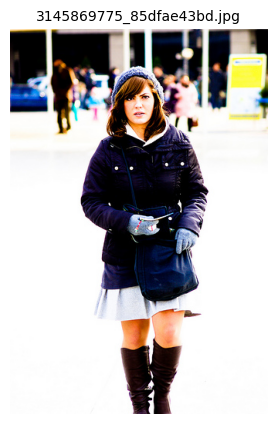


════════════════════════════════════════════════════════════════════════════════
Image: 3247598959_5b2348444c.jpg
Neutral: three dogs are running through a grassy field. one dog is wearing a white shirt, another is wearing a black shirt, and the third is wearing a brown and white striped shirt. the dogs appear to be in motion, and the grass is a vibrant green. the sky is clear and blue.
────────────────────────────────────────────────────────────────────────────────

  [Baseline]
    humorous   GEN: a brown and white dog , a black and white outfit , a gentle moment of simple joy , a quiet moment of connection .
               REF: dogs running in shirts; white, black, and stripe, a canine fashion show of questionable taste; grassy field: doing its part; sky: clear, because of course.
    joyful     GEN: a brown and white dog , a black and white outfit , a gentle moment of simple joy , a quiet moment of connection .
               REF: a flurry of fur and glee! three dogs, white shirt,

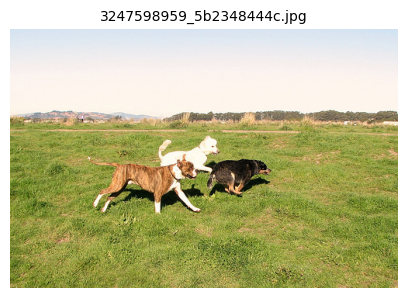


════════════════════════════════════════════════════════════════════════════════
Image: 1718184338_5968d88edb.jpg
Neutral: two people stand on a rocky outcropping overlooking a river. one person wears a white helmet and an orange and black jacket, while the other wears a blue cap and a gray jacket. the river is a light blue-green color, and the surrounding landscape is rocky and dry.
────────────────────────────────────────────────────────────────────────────────

  [Baseline]
    humorous   GEN: the man in the red shirt and blue jeans stands alone on the dirt path , a quiet moment of shared connection .
               REF: two tourists are standing out on the rocky terrain, dressed for a hike. perhaps a picnic?
    joyful     GEN: the man in the red shirt and blue jeans stands alone on the dirt path , a quiet moment of shared connection .
               REF: two people, one in orange and one in gray, joyfully stand on a rocky outcropping, admiring the blue-green river and arid landsc

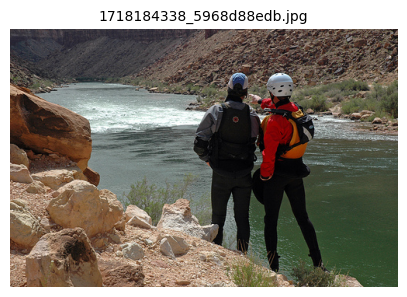

In [10]:
import matplotlib.pyplot as plt

# Pick 3 random test images
random.seed(0)
test_imgs = random.sample(test_df['image_id'].unique().tolist(), 3)

for img_id in test_imgs:
    print("\n" + "═" * 80)
    print(f"Image: {img_id}")
    sub = test_df[test_df['image_id'] == img_id]
    print(f"Neutral: {sub.iloc[0]['neutral_caption']}")
    print("─" * 80)

    # Load feature
    feat = torch.load(
        os.path.join(FEATURE_DIR, f"{img_id.rsplit('.', 1)[0]}.pt"),
        weights_only=True
    ).unsqueeze(0).to(device)

    for model_name, model in trained_models.items():
        print(f"\n  [{model_name}]")
        for emo in EMOTIONS:
            emo_id  = torch.tensor([EMOTION2ID[emo]], device=device)
            tokens  = beam_search(model, feat, emo_id, beam_size=4)
            cap     = local_ids_to_text(tokens)
            gt_row  = sub[sub['emotion'] == emo]
            gt      = gt_row.iloc[0]['emotion_caption'] if len(gt_row) else ''
            print(f"    {emo:9s}  GEN: {cap}")
            if gt:
                print(f"               REF: {gt}")

    # Show the image
    try:
        img = Image.open(os.path.join(IMG_BASE_DIR, img_id)).convert('RGB')
        plt.figure(figsize=(5, 5))
        plt.imshow(img); plt.axis('off'); plt.title(img_id, fontsize=10)
        plt.show()
    except Exception as e:
        print(f"  (couldn't display image: {e})")

## 📈 Step 13: Training Curves

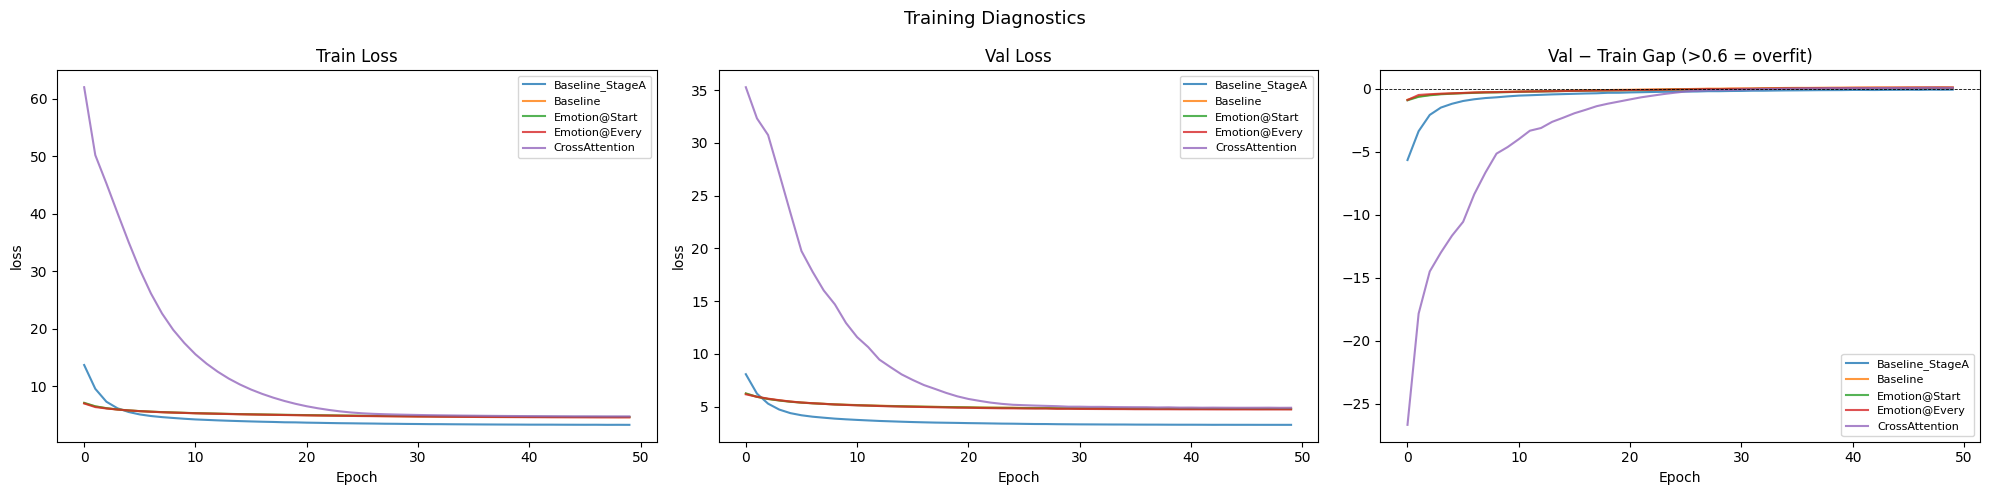


Final val−train gap (lower is better):
  Baseline_StageA   : gap=-0.0583  best_val=3.2751  ✅
  Baseline          : gap=+0.1338  best_val=4.8066  ✅
  Emotion@Start     : gap=+0.0749  best_val=4.7748  ✅
  Emotion@Every     : gap=+0.1023  best_val=4.7316  ✅
  CrossAttention    : gap=+0.0953  best_val=4.8907  ✅


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Training Diagnostics', fontsize=13)

for name, h in histories.items():
    gap = [v - t for t, v in zip(h['train'], h['val'])]
    axes[0].plot(h['train'], label=name, alpha=0.8)
    axes[1].plot(h['val'],   label=name, alpha=0.8)
    axes[2].plot(gap,        label=name, alpha=0.8)

axes[0].set(title='Train Loss',  xlabel='Epoch', ylabel='loss'); axes[0].legend(fontsize=8)
axes[1].set(title='Val Loss',    xlabel='Epoch', ylabel='loss'); axes[1].legend(fontsize=8)
axes[2].axhline(0, color='black', linestyle='--', lw=0.6)
axes[2].set(title='Val − Train Gap (>0.6 = overfit)', xlabel='Epoch')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/training_curves.png', dpi=120)
plt.show()

# Final overfitting summary
print("\nFinal val−train gap (lower is better):")
for name, h in histories.items():
    if not h['val']:
        continue
    gap  = h['val'][-1] - h['train'][-1]
    flag = '⚠️  overfit' if gap > 0.6 else '✅'
    print(f"  {name:18s}: gap={gap:+.4f}  best_val={min(h['val']):.4f}  {flag}")

## 💾 Step 14: Save Everything

In [ ]:
# Histories
with open(f'{WORKING_DIR}/training_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

# BLEU results
with open(f'{WORKING_DIR}/bleu_results.pkl', 'wb') as f:
    pickle.dump({'overall': bleu_results, 'per_emotion': bleu_per_emo}, f)

# List saved files
print("✅ Files in working dir:")
for fname in sorted(os.listdir(WORKING_DIR)):
    fp = os.path.join(WORKING_DIR, fname)
    if os.path.isfile(fp):
        print(f"   {fname:42s}  {os.path.getsize(fp)/1e6:7.2f} MB")

## 🩺 Diagnostics — what to do if things go wrong

| Symptom | Likely cause | Fix |
|---|---|---|
| Stage A val loss stuck around 5.0 | Vocab too big or LR too high | Drop `MIN_TOKEN_FREQ` to 2 in Notebook 2 (more vocab) or set `BASE_LR_STAGE_A=2e-4` |
| Stage A goes well, Stage B overfits hard | Emotion captions diverge too much from neutral; transfer doesn't help | Loosen the filters in Notebook 2 (`MIN_QUALITY=0.4`, `MIN_VOCAB_OVERLAP=0.15`) — gives more training data |
| All emotions produce same caption | `emo_embed` not learning | `print(model.emo_embed.weight.grad)` — must be non-None. Try `BASE_LR_STAGE_B=5e-4` to give it more signal. |
| Beam search slow | n_test * beam_size * seq_len is large | Pass `n_max=200` to `compute_bleu` for a quick estimate |
| CrossAttention BLEU much worse than others | Attention layers not converged | Increase `STAGE_B_EPOCHS` to 30 specifically for it; or set its `lr=1e-4` |
| OOM | `BATCH_SIZE` too high for T4 | Reduce to 32 |
